# Electronic Band Structure of Monolayer MoS₂ Using the Tight-Binding Method

This notebook implements an eleven-orbital Slater–Koster Tight-Binding model to calculate and visualize the electronic band structure of monolayer MoS₂.

In [1]:
import numpy as np
import matplotlib.pylab as plt
from matplotlib.pyplot import figure



## Import Required Libraries

Import the numerical and plotting libraries used throughout the notebook.

In [2]:
E=[]
pi=np.pi 
a=0.316
teta=np.pi*((46.5)/180)
#every unit cell has three atom 2S and 1Mo
VppP=-2.28 
VppS=0.768
VpdS=-2.105
VpdP=-1.014
VddS=-0.739
VddP=0.716
VddD=-0.065
r1=np.array([a/2,a*np.sqrt(3)/2])
r2=np.array([-a/2,a*np.sqrt(3)/2])
D0=-0.004
D1=0.165
D2=0.100
DP=-1.966
DZ=-2.125





## Physical Parameters

Define lattice constants, onsite energies, and Slater–Koster hopping integrals.

In [3]:
t=np.zeros((5,3), dtype=complex)
t[0,1]=(np.cos(teta)*(1.5*np.sin(teta)*np.sin(teta)-0.5)*VpdS)-np.sqrt(3)*np.sin(teta)*np.sin(teta)*np.cos(teta)*VpdP
t[0,2]=(np.sin(teta)*(1.5*np.sin(teta)*np.sin(teta)-0.5)*VpdS)+np.sqrt(3)*np.sin(teta)*np.cos(teta)*np.cos(teta)*VpdP
t[1,1]=-(np.sqrt(3)*np.cos(teta)*np.cos(teta)*np.cos(teta)*VpdS)/2-np.cos(teta)*np.sin(teta)*np.sin(teta)*VpdP
t[1,2]=-np.sin(teta)*np.cos(teta)*np.cos(teta)*(np.sqrt(3)*VpdS/2-VpdP)
t[2,0]=np.cos(teta)*VpdP
t[3,0]=np.sin(teta)*VpdP
t[4,1]=np.sqrt(3)*np.cos(teta)*np.cos(teta)*np.sin(teta)*VpdS+np.sin(teta)*(1-2*np.cos(teta)*np.cos(teta))*VpdP
t[4,2]=np.sqrt(3)*np.sin(teta)*np.cos(teta)*np.sin(teta)*VpdS+np.cos(teta)*(1-2*np.sin(teta)*np.sin(teta))*VpdP
tb=np.zeros((5,3), dtype=complex)
tb[0,1]=(np.cos(teta)*(1.5*np.sin(teta)*np.sin(teta)-0.5)*VpdS)-np.sqrt(3)*np.sin(teta)*np.sin(teta)*np.cos(teta)*VpdP
tb[0,2]=-((np.sin(teta)*(1.5*np.sin(teta)*np.sin(teta)-0.5)*VpdS)-np.sqrt(3)*np.sin(teta)*np.cos(teta)*np.cos(teta)*VpdP)
tb[1,1]=-(np.sqrt(3)*np.cos(teta)*np.cos(teta)*np.cos(teta)*VpdS)/2-np.cos(teta)*np.sin(teta)*np.sin(teta)*VpdP
tb[1,2]=np.sin(teta)*np.cos(teta)*np.cos(teta)*(np.sqrt(3)/2*VpdS-VpdP)
tb[2,0]=np.cos(teta)*VpdP
tb[3,0]=-np.sin(teta)*VpdP
tb[4,1]=-np.sqrt(3)*np.cos(teta)*np.cos(teta)*np.sin(teta)*VpdS-np.sin(teta)*(1-2*np.cos(teta)*np.cos(teta))*VpdP
tb[4,2]=np.sqrt(3)*np.sin(teta)*np.cos(teta)*np.sin(teta)*VpdS+np.cos(teta)*(1-2*np.sin(teta)*np.sin(teta))*VpdP
tl=np.zeros((5,3), dtype=complex)
tl[0,0]=-(np.sqrt(3)/2*np.cos(teta)*(3/2*np.sin(teta)*np.sin(teta)-1/2)*VpdS)+(3/2*np.sin(teta)*np.sin(teta)*np.cos(teta)*VpdP)
tl[0,1]=-(1/2*np.cos(teta)*(3/2*np.sin(teta)*np.sin(teta)-1/2)*VpdS)+(np.sqrt(3)/2*np.sin(teta)*np.sin(teta)*np.cos(teta)*VpdP)
tl[0,2]=(np.sin(teta)*(3/2*np.sin(teta)*np.sin(teta)-1/2)*VpdS)+(np.sqrt(3)*np.sin(teta)*np.cos(teta)*np.cos(teta)*VpdP)
tl[1,0]=-(3/8*np.cos(teta)*np.cos(teta)*np.cos(teta)*VpdS)-(np.sqrt(3)/2*np.cos(teta)*(1-1/2*np.cos(teta)*np.cos(teta))*VpdP)
tl[1,1]=-(np.sqrt(3)/8*np.cos(teta)*np.cos(teta)*np.cos(teta)*VpdS)+(1/2*np.cos(teta)*(1-1/2*np.cos(teta)*np.cos(teta))*VpdP)
tl[1,2]=1/2*np.sin(teta)*np.cos(teta)*np.cos(teta)*(np.sqrt(3)/2*VpdS-VpdP)
tl[2,0]=-3/8*np.sqrt(3)*np.cos(teta)*np.cos(teta)*np.cos(teta)*VpdP-1/2*np.cos(teta)*(1-3/2*np.cos(teta)*np.cos(teta)*np.cos(teta))*VpdP
tl[2,1]=-3/8*np.cos(teta)*np.cos(teta)*np.cos(teta)*VpdP-np.sqrt(3)*1/2*np.cos(teta)*(1-3/2*np.cos(teta)*np.cos(teta)*np.cos(teta))*VpdP
tl[2,2]=np.sqrt(3)/4*np.sin(teta)*np.cos(teta)*np.cos(teta)*(np.sqrt(3)*VpdS-2*VpdP)
tl[3,0]=3*np.sqrt(3)/4*np.cos(teta)*np.cos(teta)*np.sin(teta)*VpdS+np.sin(teta)*(1-3/2*np.cos(teta)*np.cos(teta))*VpdP
tl[3,1]=np.sqrt(3)/4*np.sin(teta)*np.cos(teta)*np.cos(teta)*(np.sqrt(3)*VpdS-2*VpdP)
tl[3,2]=-3/2*np.sin(teta)*np.sin(teta)*np.cos(teta)*VpdS-np.sqrt(3)/2*np.cos(teta)*(1-2*np.sin(teta)*np.sin(teta))*VpdP
tl[4,0]=np.sqrt(3)/4*np.sin(teta)*np.cos(teta)*np.cos(teta)*(np.sqrt(3)*VpdS-2*VpdP)
tl[4,1]=np.sqrt(3)/4*np.cos(teta)*np.cos(teta)*np.sin(teta)*VpdS+np.sin(teta)*(1-1/2*np.cos(teta)*np.cos(teta))*VpdP
tl[4,2]=-np.sqrt(3)/2*np.sin(teta)*np.sin(teta)*np.cos(teta)*VpdS-1/2*np.cos(teta)*(1-2*np.sin(teta)*np.sin(teta))*VpdP
tlb=np.zeros((5,3), dtype=complex)
tlb[0,0]=tl[0,0]
tlb[0,1]=tl[0,1]
tlb[0,2]=-tl[0,2]
tlb[1,0]=tl[1,0]
tlb[1,1]=tl[1,1]
tlb[1,2]=-tl[1,2]
tlb[2,0]=tl[2,0]
tlb[2,1]=tl[2,1]
tlb[2,2]=-tl[2,2]
tlb[3,0]=-tl[3,0]
tlb[3,1]=-tl[3,1]
tlb[3,2]=tl[3,2]
tlb[4,0]=-tl[4,0]
tlb[4,1]=-tl[4,1]
tlb[4,2]=tl[4,2]
tr=np.zeros((5,3), dtype=complex)
tr[0,0]=-tl[0,0]
tr[0,1]=tl[0,1]
tr[0,2]=tl[0,2]
tr[1,0]=-tl[1,0]
tr[1,1]=tl[1,1]
tr[1,2]=tl[1,2]
tr[2,0]=tl[2,0]
tr[2,1]=-tl[2,1]
tr[2,2]=-tl[2,2]
tr[3,0]=tl[3,0]
tr[3,1]=-tl[3,1]
tr[3,2]=-tl[3,2]
tr[4,0]=-tl[4,0]
tr[4,1]=tl[4,1]
tr[4,2]=tl[4,2]
trb=np.zeros((5,3), dtype=complex)
trb[0,0]=-tl[0,0]
trb[0,1]=-tl[0,0]
trb[0,2]=-tl[0,2]
trb[1,0]=tl[1,0]
trb[1,1]=tl[1,1]
trb[1,2]=-tl[1,2]
trb[2,0]=tl[2,0]
trb[2,1]=-tl[2,1]
trb[2,2]=tl[2,2]
trb[3,0]=-tl[3,0]
trb[3,1]=tl[3,1]
trb[3,2]=-tl[3,2]
trb[4,0]=tl[4,0]
trb[4,1]=-tl[4,1]
trb[4,2]=tl[4,2]







## Hamiltonian Construction

Construct the Tight-Binding Hamiltonian from the orbital interactions.

In [4]:
ve=np.zeros((5,5), dtype=complex)
ve[0,0]=1/4*VddS+3/4*VddD
ve[1,0]=-np.sqrt(3)/4*VddS+np.sqrt(3)/4*VddD
ve[0,1]=ve[1,0]
ve[1,1]=3/4*VddS+1/4*VddD
ve[2,2]=VddP
ve[3,3]=VddP
ve[4,4]=VddD
vw=np.zeros((5,5), dtype=complex)
vw[0,0]=1/4*VddS+3/4*VddD
vw[1,0]=-np.sqrt(3)/4*VddS+np.sqrt(3)/4*VddD
vw[0,1]=vw[1,0]
vw[1,1]=3/4*VddS+1/4*VddD
vw[2,2]=VddP
vw[3,3]=VddP
vw[4,4]=VddD
vne=np.zeros((5,5), dtype=complex)
vne[0,0]=ve[0,0]
vne[1,0]=-1/2*ve[1,0]
vne[0,1]=-1/2*ve[1,0]
vne[2,0]=-3/8*VddS+3/8*VddD
vne[0,2]=-3/8*VddS+3/8*VddD
vne[1,2]=np.sqrt(3)*(-3/16*VddS+1/4*VddP-1/16*VddD)
vne[2,1]=vne[1,2]
vne[3,4]=np.sqrt(3)/4*VddP-np.sqrt(3)/4*VddD
vne[4,3]=vne[4,3]
vne[1,1]=ve[1,1]*1/4+3/4*ve[2,2]
vne[2,2]=ve[2,2]*1/4+ve[1,1]*1/4
vne[3,3]=ve[3,3]/4+ve[4,4]*3/4
vne[4,4]=ve[3,3]*3/4+ve[4,4]/4
vnw=np.zeros((5,5), dtype=complex)
vnw[0,0]=1/4*VddS+3/4*VddD
vnw[1,0]=-1*np.sqrt(3)/8*VddS-np.sqrt(3)/8*VddD
vnw[0,1]=-1*np.sqrt(3)/8*VddS-np.sqrt(3)/8*VddD
vnw[2,0]=3/8*VddS-3/8*VddD
vnw[0,2]=3/8*VddS-3/8*VddD
vnw[3,4]=-np.sqrt(3)*VddP+np.sqrt(3)/4*VddD
vnw[4,3]=vne[4,3]
vnw[2,1]=-vne[2,1]
vnw[1,2]=-vne[2,1]
vnw[1,1]=ve[1,1]*1/4+3/4*ve[2,2]
vnw[2,2]=ve[2,2]*1/4+ve[1,1]*1/4
vnw[3,3]=ve[3,3]/4+ve[4,4]*3/4
vnw[4,4]=ve[3,3]*3/4+ve[4,4]/4
v=np.zeros((5,5), dtype=complex)
v=vw+vne+vnw+ve

ue=np.zeros((3,3), dtype=complex)
ue[0,0]=VppS
ue[1,1]=VppP
ue[2,2]=VppP
une=np.zeros((3,3), dtype=complex)
une[0,0]=ue[0,0]/4+3/4*ue[1,1]
une[1,1]=ue[0,0]*3/4+1/4*ue[1,1]
une[2,2]=VppP
une[0,1]=np.sqrt(3)/4*(VppS-VppP)
une[1,0]=une[0,1]
unw=np.zeros((3,3), dtype=complex)
unw[0,0]=ue[0,0]/4+3/4*ue[1,1]
unw[1,1]=ue[0,0]*3/4+1/4*ue[1,1]
unw[2,2]=VppP
une[0,1]=-np.sqrt(3)/4*(VppS-VppP)
une[1,0]=une[0,1]
u=np.zeros((3,3), dtype=complex)
u=ue+une+unw
hMo=np.zeros((5,5), dtype=complex)
hMo[0,0]=D0
hMo[1,1]=D2
hMo[2,2]=D2
hMo[3,3]=D1
hMo[4,4]=D1
hs=np.zeros((3,3), dtype=complex)
hs[0,0]=DP
hs[1,1]=DP
hs[2,2]=DZ
s=np.zeros((3,3), dtype=complex)
s[0,0]=VppP
s[1,1]=VppP
s[2,2]=VppS




## Band Structure Calculation

Diagonalize the Hamiltonian along the high-symmetry k-path.

C:\Users\10\anaconda3\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\10\anaconda3\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\10\AppData\Local\Temp\ipykernel_22632\2024985846.py:566: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


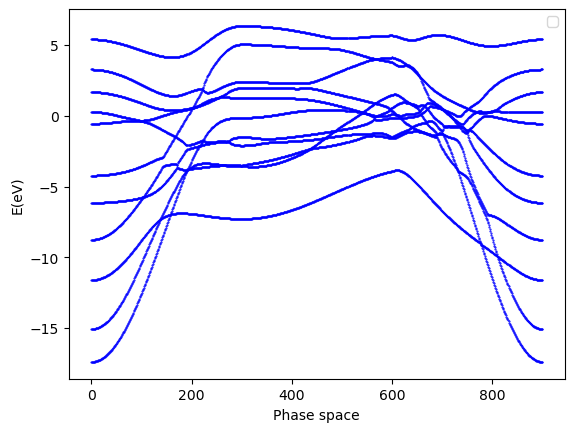

In [5]:

k1=np.linspace(0,2*pi/(np.sqrt(3)*a) ,300)
kx=0

for ky in k1:
        K=np.array([kx,ky])
        z1=np.exp(1j*np.dot(K,r1))
        z2=np.exp(1j*np.dot(K,r2))
        z2_=np.exp(-1j*np.dot(K,r2))
        c1=np.cos(np.dot(K,r1))
        c2=np.cos(np.dot(K,r2))
        c12=np.cos(np.dot(K,r1)-np.dot(K,r2))
        Tt=t+z2_*(tl+z1*tr)
        Tb=tb+z2_*(tlb+z1*trb)
        v=2*(c2*vne+c12*vnw+c1*ve)
        u=2*(c1*ue+c2*une+c12*unw)
        Tt_= np.transpose(Tt)
        Tb_= np.transpose(Tb)
        
        Tn=np.zeros((11,11), dtype=complex)
        Tn[0,0]=hMo[0,0]+v[0,0]
        Tn[1,1]=hMo[1,1]+v[1,1]
        Tn[2,2]=hMo[2,2]+v[2,2]
        Tn[3,3]=hMo[3,3]+v[3,3]
        Tn[4,4]=hMo[4,4]+v[4,4]
        Tn[1,0]=v[1,0]
        Tn[2,0]=v[2,0]
        Tn[0,1]=v[0,1]
        Tn[0,1]=v[0,2]
        Tn[1,2]=v[1,2]
        Tn[1,1]=v[2,1]
        Tn[3,4]=v[3,4]
        Tn[4,3]=v[4,3]
        Tn[0,5]=Tt[0,0]
        Tn[1,5]=Tt[1,0]
        Tn[2,5]=Tt[2,0]
        Tn[3,5]=Tt[3,0]
        Tn[4,5]=Tt[4,0]

        Tn[0,6]=Tt[0,1]

        Tn[1,6]=Tt[1,1]

        Tn[2,6]=Tt[2,1]

        Tn[3,6]=Tt[3,1]

        Tn[4,6]=Tt[4,1]

        Tn[0,7]=Tt[0,2]

        Tn[1,7]=Tt[1,2]

        Tn[2,7]=Tt[2,2]

        Tn[3,7]=Tt[3,2]

        Tn[4,7]=Tt[4,2]

        Tn[0,8]=Tb[0,0]

        Tn[1,8]=Tb[1,0]

        Tn[2,8]=Tb[2,0]

        Tn[3,8]=Tb[3,0]

        Tn[4,8]=Tb[4,0]

        Tn[0,9]=Tb[0,1]

        Tn[1,9]=Tb[1,1]

        Tn[2,9]=Tb[2,1]

        Tn[3,9]=Tb[3,1]

        Tn[4,9]=Tb[4,1]

        Tn[0,10]=Tb[0,2]

        Tn[1,10]=Tb[1,2]

        Tn[2,10]=Tb[2,2]

        Tn[3,10]=Tb[3,2]

        Tn[4,10]=Tb[4,2]


        Tn[5,0]=Tt_[0,0]

        Tn[5,1]=Tt_[0,1]

        Tn[5,2]=Tt_[0,2]

        Tn[5,3]=Tt_[0,3]

        Tn[6,0]=Tt_[0,1]

        Tn[6,1]=Tt_[1,1]

        Tn[6,2]=Tt_[1,2]

        Tn[6,3]=Tt_[1,3]

        Tn[6,4]=Tt_[1,4]

        Tn[7,0]=Tt_[2,0]

        Tn[7,1]=Tt_[2,1]

        Tn[7,2]=Tt_[2,2]

        Tn[7,3]=Tt_[2,3]

        Tn[7,4]=Tt_[2,4]

        Tn[8,0]=Tb_[0,0]

        Tn[8,1]=Tb_[0,1]

        Tn[8,2]=Tb_[0,2]

        Tn[8,3]=Tb_[0,3]

        Tn[8,4]=Tb_[0,4]

        Tn[9,0]=Tb_[1,0]

        Tn[9,1]=Tb_[1,1]

        Tn[9,2]=Tb_[1,2]

        Tn[9,3]=Tb_[1,3]

        Tn[9,4]=Tb_[1,4]

        Tn[10,0]=Tb_[2,0]

        Tn[10,1]=Tb_[2,1]

        Tn[10,2]=Tb_[2,2]

        Tn[10,3]=Tb_[2,3]

        Tn[10,4]=Tb_[2,4]


        Tn[5,8]=s[0,0]

        Tn[6,9]=s[1,1]

        Tn[7,10]=s[2,2]


        Tn[8,5]=s[0,0]

        Tn[9,6]=s[1,1]

        Tn[10,7]=s[2,2]


        Tn[5,5]=hs[0,0]+u[0,0]

        Tn[5,6]=u[0,1]

        Tn[6,5]=u[1,0]

        Tn[6,6]=hs[1,1]+u[1,1]

        Tn[7,7]=hs[2,2]+u[2,2]


        Tn[8,8]=hs[0,0]+u[0,0]

        Tn[8,9]=u[0,1]

        Tn[9,8]=u[1,0]

        Tn[9,9]=hs[1,1]+u[1,1]

        Tn[10,10]=hs[2,2]+u[2,2]
        Eval,Evec=np.linalg.eig(Tn)
        E.append(Eval)



k2=np.linspace(0,2*pi/(3*a) ,300)

ky=2*pi/(np.sqrt(3)*a)
for kx in k2:
        K=np.array([kx,ky])
        z1=np.exp(1j*np.dot(K,r1))
        z2=np.exp(1j*np.dot(K,r2))
        z2_=np.exp(-1j*np.dot(K,r2))
        c1=np.cos(np.dot(K,r1))
        c2=np.cos(np.dot(K,r2))
        c12=np.cos(np.dot(K,r1)-np.dot(K,r2))
        Tt=t+z2_*(tl+z1*tr)
        Tb=tb+z2_*(tlb+z1*trb)
        v=2*(c2*vne+c12*vnw+c1*ve)
        u=2*(c1*ue+c2*une+c12*unw)
        Tt_= np.transpose(Tt)
        Tb_= np.transpose(Tb)
        
        Tn=np.zeros((11,11), dtype=complex)
        Tn[0,0]=hMo[0,0]+v[0,0]
        Tn[1,1]=hMo[1,1]+v[1,1]
        Tn[2,2]=hMo[2,2]+v[2,2]
        Tn[3,3]=hMo[3,3]+v[3,3]
        Tn[4,4]=hMo[4,4]+v[4,4]
        Tn[1,0]=v[1,0]
        Tn[2,0]=v[2,0]
        Tn[0,1]=v[0,1]
        Tn[0,1]=v[0,2]
        Tn[1,2]=v[1,2]
        Tn[1,1]=v[2,1]
        Tn[3,4]=v[3,4]
        Tn[4,3]=v[4,3]
        Tn[0,5]=Tt[0,0]
        Tn[1,5]=Tt[1,0]
        Tn[2,5]=Tt[2,0]
        Tn[3,5]=Tt[3,0]

        Tn[4,5]=Tt[4,0]

        Tn[0,6]=Tt[0,1]

        Tn[1,6]=Tt[1,1]

        Tn[2,6]=Tt[2,1]

        Tn[3,6]=Tt[3,1]

        Tn[4,6]=Tt[4,1]

        Tn[0,7]=Tt[0,2]

        Tn[1,7]=Tt[1,2]

        Tn[2,7]=Tt[2,2]

        Tn[3,7]=Tt[3,2]

        Tn[4,7]=Tt[4,2]

        Tn[0,8]=Tb[0,0]

        Tn[1,8]=Tb[1,0]

        Tn[2,8]=Tb[2,0]

        Tn[3,8]=Tb[3,0]

        Tn[4,8]=Tb[4,0]

        Tn[0,9]=Tb[0,1]

        Tn[1,9]=Tb[1,1]

        Tn[2,9]=Tb[2,1]

        Tn[3,9]=Tb[3,1]

        Tn[4,9]=Tb[4,1]

        Tn[0,10]=Tb[0,2]

        Tn[1,10]=Tb[1,2]

        Tn[2,10]=Tb[2,2]

        Tn[3,10]=Tb[3,2]

        Tn[4,10]=Tb[4,2]


        Tn[5,0]=Tt_[0,0]

        Tn[5,1]=Tt_[0,1]

        Tn[5,2]=Tt_[0,2]

        Tn[5,3]=Tt_[0,3]

        Tn[6,0]=Tt_[0,1]

        Tn[6,1]=Tt_[1,1]

        Tn[6,2]=Tt_[1,2]

        Tn[6,3]=Tt_[1,3]

        Tn[6,4]=Tt_[1,4]

        Tn[7,0]=Tt_[2,0]

        Tn[7,1]=Tt_[2,1]

        Tn[7,2]=Tt_[2,2]

        Tn[7,3]=Tt_[2,3]

        Tn[7,4]=Tt_[2,4]

        Tn[8,0]=Tb_[0,0]

        Tn[8,1]=Tb_[0,1]

        Tn[8,2]=Tb_[0,2]

        Tn[8,3]=Tb_[0,3]

        Tn[8,4]=Tb_[0,4]

        Tn[9,0]=Tb_[1,0]

        Tn[9,1]=Tb_[1,1]

        Tn[9,2]=Tb_[1,2]

        Tn[9,3]=Tb_[1,3]

        Tn[9,4]=Tb_[1,4]

        Tn[10,0]=Tb_[2,0]

        Tn[10,1]=Tb_[2,1]

        Tn[10,2]=Tb_[2,2]

        Tn[10,3]=Tb_[2,3]

        Tn[10,4]=Tb_[2,4]


        Tn[5,8]=s[0,0]

        Tn[6,9]=s[1,1]

        Tn[7,10]=s[2,2]


        Tn[8,5]=s[0,0]

        Tn[9,6]=s[1,1]

        Tn[10,7]=s[2,2]


        Tn[5,5]=hs[0,0]+u[0,0]

        Tn[5,6]=u[0,1]

        Tn[6,5]=u[1,0]

        Tn[6,6]=hs[1,1]+u[1,1]

        Tn[7,7]=hs[2,2]+u[2,2]


        Tn[8,8]=hs[0,0]+u[0,0]

        Tn[8,9]=u[0,1]

        Tn[9,8]=u[1,0]

        Tn[9,9]=hs[1,1]+u[1,1]

        Tn[10,10]=hs[2,2]+u[2,2]
        Eval,Evec=np.linalg.eig(Tn)
        E.append(Eval)

       
k3=np.linspace(2*pi/(3*a),0 ,300)

for kx in k3:
        ky=kx*np.sqrt(3)
        K=np.array([kx,ky])
        z1=np.exp(1j*np.dot(K,r1))
        z2=np.exp(1j*np.dot(K,r2))
        z2_=np.exp(-1j*np.dot(K,r2))
        c1=np.cos(np.dot(K,r1))
        c2=np.cos(np.dot(K,r2))
        c12=np.cos(np.dot(K,r1)-np.dot(K,r2))
        Tt=t+z2_*(tl+z1*tr)
        Tb=tb+z2_*(tlb+z1*trb)
        v=2*(c2*vne+c12*vnw+c1*ve)
        u=2*(c1*ue+c2*une+c12*unw)
        Tt_= np.transpose(Tt)
        Tb_= np.transpose(Tb)
        
        Tn=np.zeros((11,11), dtype=complex)
        Tn[0,0]=hMo[0,0]+v[0,0]
        Tn[1,1]=hMo[1,1]+v[1,1]
        Tn[2,2]=hMo[2,2]+v[2,2]
        Tn[3,3]=hMo[3,3]+v[3,3]
        Tn[4,4]=hMo[4,4]+v[4,4]
        Tn[1,0]=v[1,0]
        Tn[2,0]=v[2,0]
        Tn[0,1]=v[0,1]
        Tn[0,1]=v[0,2]
        Tn[1,2]=v[1,2]
        Tn[1,1]=v[2,1]
        Tn[3,4]=v[3,4]
        Tn[4,3]=v[4,3]
        Tn[0,5]=Tt[0,0]
        Tn[1,5]=Tt[1,0]
        Tn[2,5]=Tt[2,0]
        Tn[3,5]=Tt[3,0]

        Tn[4,5]=Tt[4,0]

        Tn[0,6]=Tt[0,1]

        Tn[1,6]=Tt[1,1]

        Tn[2,6]=Tt[2,1]

        Tn[3,6]=Tt[3,1]

        Tn[4,6]=Tt[4,1]

        Tn[0,7]=Tt[0,2]

        Tn[1,7]=Tt[1,2]

        Tn[2,7]=Tt[2,2]

        Tn[3,7]=Tt[3,2]

        Tn[4,7]=Tt[4,2]

        Tn[0,8]=Tb[0,0]

        Tn[1,8]=Tb[1,0]

        Tn[2,8]=Tb[2,0]

        Tn[3,8]=Tb[3,0]

        Tn[4,8]=Tb[4,0]

        Tn[0,9]=Tb[0,1]

        Tn[1,9]=Tb[1,1]

        Tn[2,9]=Tb[2,1]

        Tn[3,9]=Tb[3,1]

        Tn[4,9]=Tb[4,1]

        Tn[0,10]=Tb[0,2]

        Tn[1,10]=Tb[1,2]

        Tn[2,10]=Tb[2,2]

        Tn[3,10]=Tb[3,2]

        Tn[4,10]=Tb[4,2]


        Tn[5,0]=Tt_[0,0]

        Tn[5,1]=Tt_[0,1]

        Tn[5,2]=Tt_[0,2]

        Tn[5,3]=Tt_[0,3]

        Tn[6,0]=Tt_[0,1]

        Tn[6,1]=Tt_[1,1]

        Tn[6,2]=Tt_[1,2]

        Tn[6,3]=Tt_[1,3]

        Tn[6,4]=Tt_[1,4]

        Tn[7,0]=Tt_[2,0]

        Tn[7,1]=Tt_[2,1]

        Tn[7,2]=Tt_[2,2]

        Tn[7,3]=Tt_[2,3]

        Tn[7,4]=Tt_[2,4]

        Tn[8,0]=Tb_[0,0]

        Tn[8,1]=Tb_[0,1]

        Tn[8,2]=Tb_[0,2]

        Tn[8,3]=Tb_[0,3]

        Tn[8,4]=Tb_[0,4]

        Tn[9,0]=Tb_[1,0]

        Tn[9,1]=Tb_[1,1]

        Tn[9,2]=Tb_[1,2]

        Tn[9,3]=Tb_[1,3]

        Tn[9,4]=Tb_[1,4]

        Tn[10,0]=Tb_[2,0]

        Tn[10,1]=Tb_[2,1]

        Tn[10,2]=Tb_[2,2]

        Tn[10,3]=Tb_[2,3]

        Tn[10,4]=Tb_[2,4]


        Tn[5,8]=s[0,0]

        Tn[6,9]=s[1,1]

        Tn[7,10]=s[2,2]


        Tn[8,5]=s[0,0]

        Tn[9,6]=s[1,1]

        Tn[10,7]=s[2,2]


        Tn[5,5]=hs[0,0]+u[0,0]

        Tn[5,6]=u[0,1]

        Tn[6,5]=u[1,0]

        Tn[6,6]=hs[1,1]+u[1,1]

        Tn[7,7]=hs[2,2]+u[2,2]


        Tn[8,8]=hs[0,0]+u[0,0]

        Tn[8,9]=u[0,1]

        Tn[9,8]=u[1,0]

        Tn[9,9]=hs[1,1]+u[1,1]

        Tn[10,10]=hs[2,2]+u[2,2]
        Eval,Evec=np.linalg.eig(Tn)
        E.append(Eval)

           
    
plt.plot(E,'b.',linewidth=2,markersize=1)
plt.ylabel('E(eV)')
plt.xlabel('Phase space')
plt.legend()
plt.savefig("my_plot.png", dpi=900)
plt.show()


## Visualization and Conclusion

Plot the calculated band structure and discuss the results.